In [6]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [9]:
tcm_df = pd.read_csv("../Data/tcm_social_data_1year.csv")
tcm_df.shape
tcm_df.head()
tcm_df.columns


(9292, 19)

,content_type,creation_time,hashtags,id,is_branded_content,lang,match_type,mcl_url,modified_time,multimedia,post_owner.id,post_owner.name,post_owner.type,post_owner.username,statistics.comment_count,statistics.like_count,statistics.views,statistics.views_date_last_refreshed,text
0,albums,2025-11-13T22:58:26+00:00,"[""1""]",27127889526849949,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-11-13T22:59:24+00:00,"[{""id"":""993416640069700"",""type"":""photo"",""url"":...",7440718489305156,Dr. Brittany | Acupuncture | Fertility | Pregn...,creator,doctor.mamabear,10.0,32.0,921.0,2026-05-22,Most mamas are told to wait on allergen foods…...
1,albums,2025-11-13T22:02:06+00:00,NaN,1022065817434502,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-12-23T09:15:56+00:00,"[{""id"":""954924990679364"",""type"":""photo"",""url"":...",1834772577120016,Dave Casey,business,dave_casey_91,11.0,NaN,8923.0,2026-05-22,The New War Horse🐴 😈 - SEVEN82MOTORS TCM Comm...
2,videos,2025-11-13T21:34:56+00:00,NaN,1564262614583311,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-11-16T11:55:15+00:00,"[{""id"":""1564262614583311"",""type"":""video"",""dura...",4203096430017796,Catarina Oliveira,creator,oliveiracatarina,0.0,11.0,347.0,2026-05-22,You should really be eating warm food. \nIn Tr...
3,albums,2025-11-13T21:04:33+00:00,"[""tattoos"",""txtattoo"",""thetexaschainsawmassacr...",971250505875088,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-11-29T17:16:52+00:00,NaN,1501838428050873,CHRISTIAN FLORES,creator,christianflorestattooer,10.0,98.0,11665.0,2026-05-22,LEATHERFACE… This tattoo is special. Beyond th...
4,photos,2025-11-13T20:59:23+00:00,"[""amaviwellness"",""calgarytcm"",""yycherbs"",""herb...",3645286768940969,False,en,"[""post_text""]",https://www.facebook.com/transparency-tools/co...,2025-11-13T21:00:15+00:00,"[{""id"":""3645286768940969"",""type"":""photo"",""url""...",1142105050653536,calgary acupuncture | facials | wellness | laser,creator,amaviwellnessclinic,12.0,NaN,10126.0,2026-05-22,"✨ Traditional remedies, modern results ✨\n\nHo..."


Index(['content_type', 'creation_time', 'hashtags', 'id', 'is_branded_content',
       'lang', 'match_type', 'mcl_url', 'modified_time', 'multimedia',
       'post_owner.id', 'post_owner.name', 'post_owner.type',
       'post_owner.username', 'statistics.comment_count',
       'statistics.like_count', 'statistics.views',
       'statistics.views_date_last_refreshed', 'text'],
      dtype='object')

In [11]:
# Looking at the types of Languages and types of accounts that exist
lang = tcm_df.lang.value_counts()
lang

acc_type = tcm_df["post_owner.type"].value_counts()
acc_type


lang
en    9182
id       1
Name: count, dtype: int64

post_owner.type
creator     5240
business    3931
personal     121
Name: count, dtype: int64

In [12]:

tcm_df = tcm_df[tcm_df["lang"] == "en"].copy()


tcm_df["hashtags_extracted"] = tcm_df["text"].str.findall(r"#\w+")


tcm_df["text_clean"] = tcm_df["text"].str.replace(r"#\w+", "", regex=True)

tcm_df["text_clean"] = tcm_df["text_clean"].str.replace(r"\s+", " ", regex=True).str.strip()



In [13]:
from datetime import datetime, timedelta
! pip install plotnine
import plotnine
from plotnine import *
import random
import seaborn as sns

In [14]:
tcm_df["creation_time"] = pd.to_datetime(tcm_df["creation_time"])

tcm_df["creation_time"] = tcm_df["creation_time"].dt.tz_localize(None)

tcm_df["week"] = tcm_df["creation_time"].dt.to_period("W").dt.to_timestamp()

In [15]:
df_tcm = (
    tcm_df
    .groupby(["week", "post_owner.type"])
    .size()
    .reset_index(name="count")
)
df_tcm["total"] = df_tcm.groupby("week")["count"].transform("sum")
df_tcm["proportion"] = df_tcm["count"] / df_tcm["total"]

<Figure size 2000x1000 with 0 Axes>

<Axes: xlabel='week', ylabel='proportion'>

(array([20240., 20270., 20301., 20332., 20362., 20393.]),
 [Text(20240.0, 0, '2025-06'),
  Text(20270.0, 0, '2025-07'),
  Text(20301.0, 0, '2025-08'),
  Text(20332.0, 0, '2025-09'),
  Text(20362.0, 0, '2025-10'),
  Text(20393.0, 0, '2025-11')])

(array([-0.1,  0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7]),
 [Text(0, -0.1, '−0.1'),
  Text(0, 0.0, '0.0'),
  Text(0, 0.1, '0.1'),
  Text(0, 0.20000000000000004, '0.2'),
  Text(0, 0.30000000000000004, '0.3'),
  Text(0, 0.4, '0.4'),
  Text(0, 0.5000000000000001, '0.5'),
  Text(0, 0.6000000000000001, '0.6'),
  Text(0, 0.7000000000000001, '0.7')])

Text(0.5, 0, 'Week')

Text(0, 0.5, 'Proportion of #tcm Posts')

Text(0.5, 1.0, '#tcm Posts Over Time: Creator vs Business vs Personal')

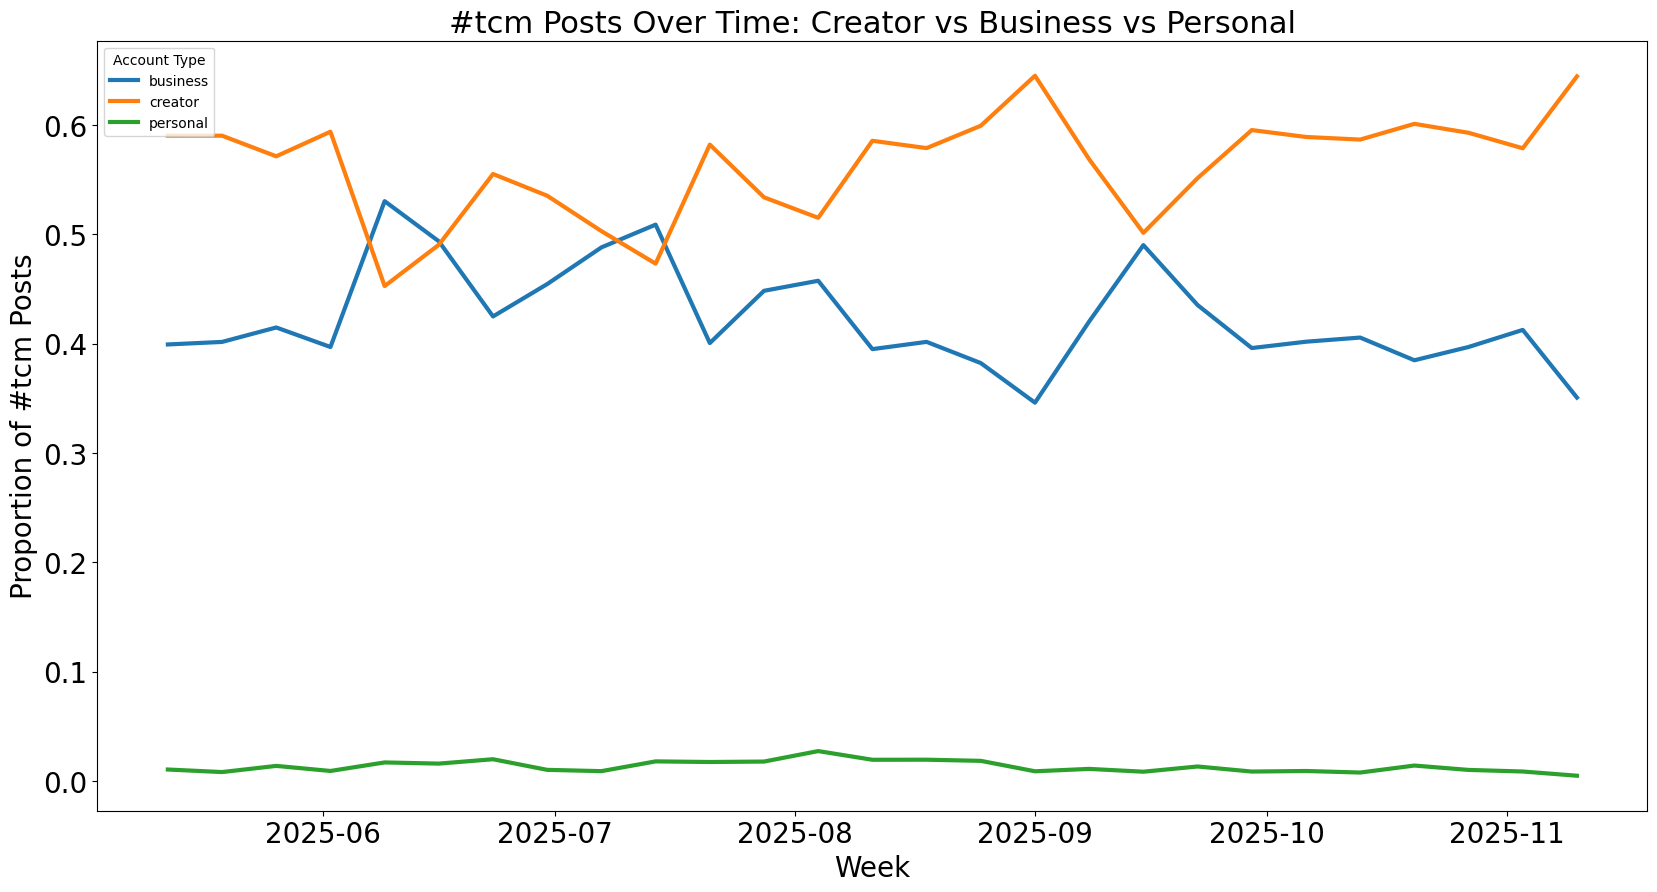

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(20,10))

sns.lineplot(
    data=df_tcm,
    x="week",
    y="proportion",
    hue="post_owner.type",
    linewidth=3
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Week", fontsize=20)
plt.ylabel("Proportion of #tcm Posts", fontsize=20)
plt.title("#tcm Posts Over Time: Creator vs Business vs Personal", fontsize=22)

plt.legend(title="Account Type")
plt.show()

plt.savefig("../Output/tcm__proportion_posts_over_time.png")

<Figure size 2000x1000 with 0 Axes>

<Axes: xlabel='week', ylabel='count'>

(array([20240., 20270., 20301., 20332., 20362., 20393.]),
 [Text(20240.0, 0, '2025-06'),
  Text(20270.0, 0, '2025-07'),
  Text(20301.0, 0, '2025-08'),
  Text(20332.0, 0, '2025-09'),
  Text(20362.0, 0, '2025-10'),
  Text(20393.0, 0, '2025-11')])

(array([-50.,   0.,  50., 100., 150., 200., 250.]),
 [Text(0, -50.0, '−50'),
  Text(0, 0.0, '0'),
  Text(0, 50.0, '50'),
  Text(0, 100.0, '100'),
  Text(0, 150.0, '150'),
  Text(0, 200.0, '200'),
  Text(0, 250.0, '250')])

Text(0.5, 0, 'Week')

Text(0, 0.5, 'Total #tcm Posts')

Text(0.5, 1.0, '#tcm Posts Over Time: Creator vs Business vs Personal')

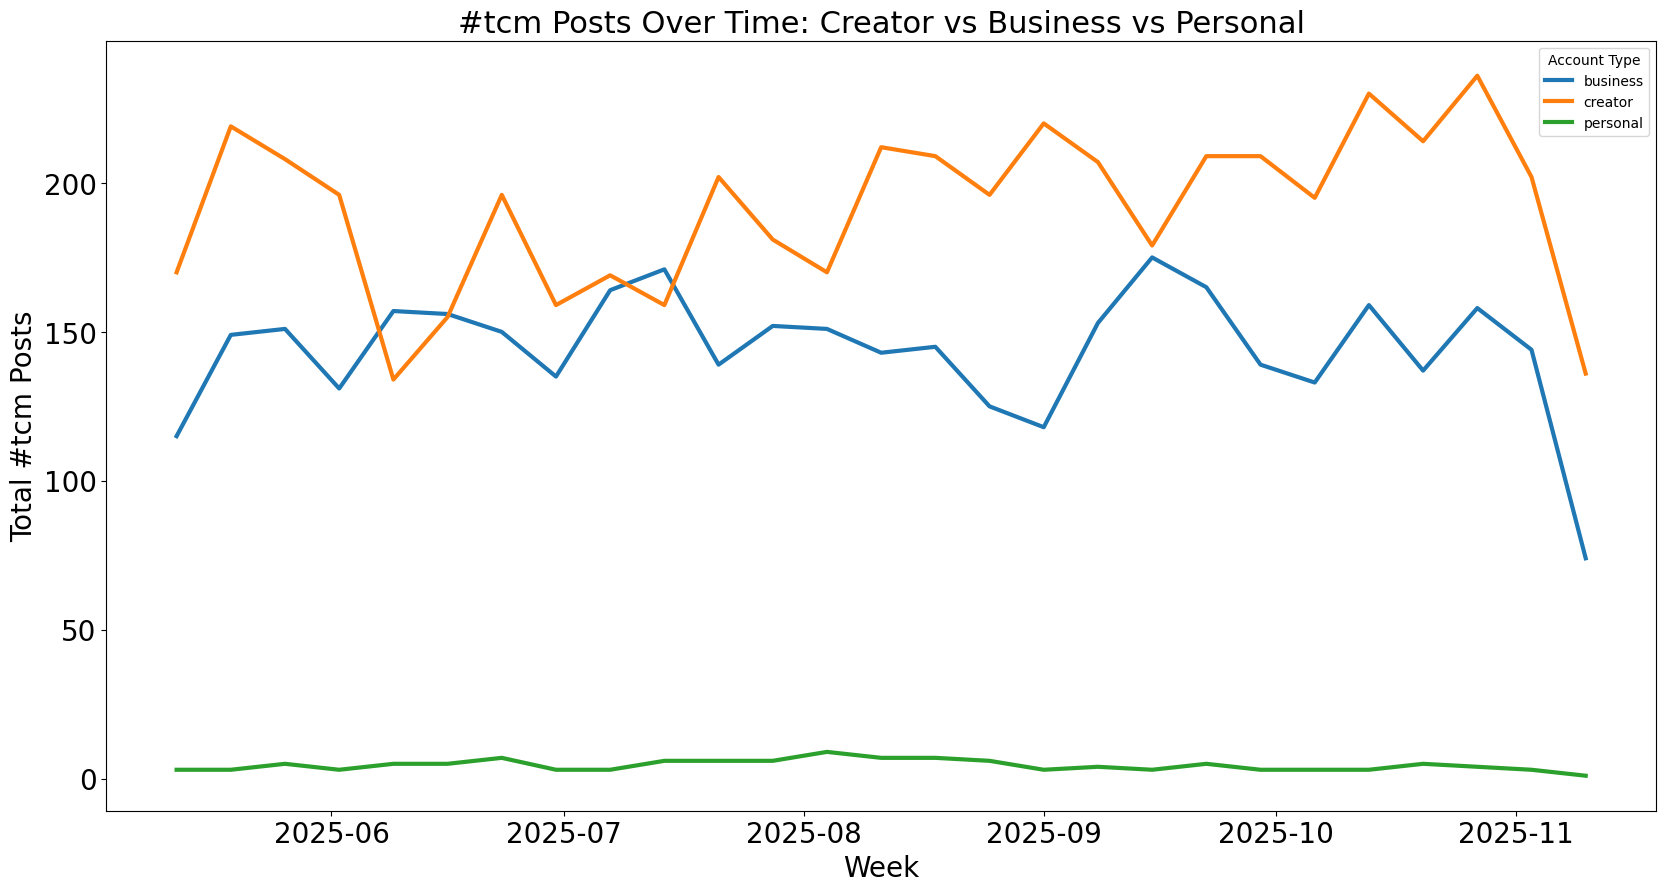

<Figure size 640x480 with 0 Axes>

In [18]:
plt.figure(figsize=(20,10))

sns.lineplot(
    data=df_tcm,
    x="week",
    y="count",
    hue="post_owner.type",
    linewidth=3
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Week", fontsize=20)
plt.ylabel("Total #tcm Posts", fontsize=20)
plt.title("#tcm Posts Over Time: Creator vs Business vs Personal", fontsize=22)

plt.legend(title="Account Type")
plt.show()
plt.savefig("../Output/tcm_posts_over_time.png")

In [20]:
df_tcm = (
    tcm_df
    .groupby(["week", "post_owner.type"])["post_owner.id"]
    .nunique()
    .reset_index(name="unique_owners")
)

df_tcm["total"] = df_tcm.groupby("week")["unique_owners"].transform("sum")

<Figure size 2000x1000 with 0 Axes>

<Axes: xlabel='week', ylabel='unique_owners'>

(array([20240., 20270., 20301., 20332., 20362., 20393.]),
 [Text(20240.0, 0, '2025-06'),
  Text(20270.0, 0, '2025-07'),
  Text(20301.0, 0, '2025-08'),
  Text(20332.0, 0, '2025-09'),
  Text(20362.0, 0, '2025-10'),
  Text(20393.0, 0, '2025-11')])

(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(0, -20.0, '−20'),
  Text(0, 0.0, '0'),
  Text(0, 20.0, '20'),
  Text(0, 40.0, '40'),
  Text(0, 60.0, '60'),
  Text(0, 80.0, '80'),
  Text(0, 100.0, '100'),
  Text(0, 120.0, '120'),
  Text(0, 140.0, '140'),
  Text(0, 160.0, '160')])

Text(0.5, 0, 'Week')

Text(0, 0.5, 'Number of Unique Users')

Text(0.5, 1.0, 'Proportion of Unique #tcm Participants Over Time by Account Type')

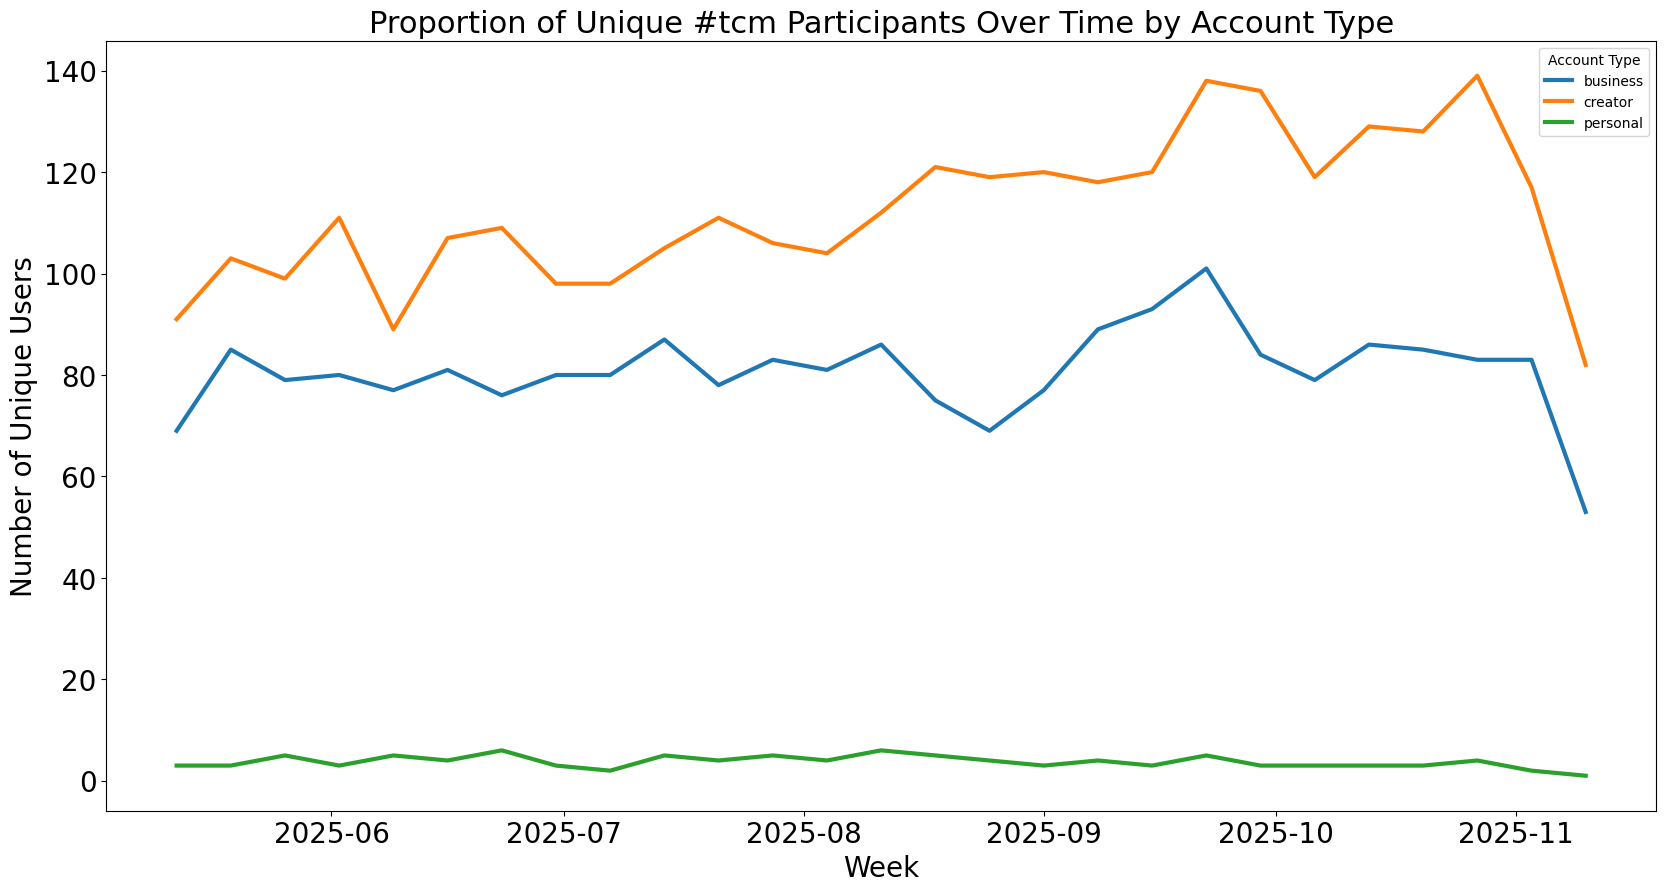

<Figure size 640x480 with 0 Axes>

In [21]:
plt.figure(figsize=(20,10))

sns.lineplot(
    data=df_tcm,
    x="week",
    y="unique_owners",
    hue="post_owner.type",
    linewidth=3
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Week", fontsize=20)
plt.ylabel("Number of Unique Users", fontsize=20)
plt.title("Proportion of Unique #tcm Participants Over Time by Account Type", fontsize=22)

plt.legend(title="Account Type")
plt.show()

plt.savefig("../Output/tcm_proportion_unique_users_over_time.png")

In [22]:
tcm_df["first_week"] = tcm_df.groupby("post_owner.id")["week"].transform("min")

tcm_df["is_new"] = tcm_df["week"] == tcm_df["first_week"]


In [23]:
new_users = (
    tcm_df[tcm_df["is_new"]]
    .groupby(["week", "post_owner.type"])["post_owner.id"]
    .nunique()
    .reset_index(name="new_users")
)

In [24]:
df_tcm = df_tcm.merge(new_users, on=["week", "post_owner.type"], how="left")
df_tcm["new_users"] = df_tcm["new_users"].fillna(0)

<Figure size 2000x1000 with 0 Axes>

<Axes: xlabel='week', ylabel='unique_owners'>

<Axes: xlabel='week', ylabel='unique_owners'>

(array([20240., 20270., 20301., 20332., 20362., 20393.]),
 [Text(20240.0, 0, '2025-06'),
  Text(20270.0, 0, '2025-07'),
  Text(20301.0, 0, '2025-08'),
  Text(20332.0, 0, '2025-09'),
  Text(20362.0, 0, '2025-10'),
  Text(20393.0, 0, '2025-11')])

(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(0, -20.0, '−20'),
  Text(0, 0.0, '0'),
  Text(0, 20.0, '20'),
  Text(0, 40.0, '40'),
  Text(0, 60.0, '60'),
  Text(0, 80.0, '80'),
  Text(0, 100.0, '100'),
  Text(0, 120.0, '120'),
  Text(0, 140.0, '140'),
  Text(0, 160.0, '160')])

Text(0.5, 0, 'Week')

Text(0, 0.5, 'Number of Users')

Text(0.5, 1.0, 'Total vs New #tcm Participants Over Time by Account Type')

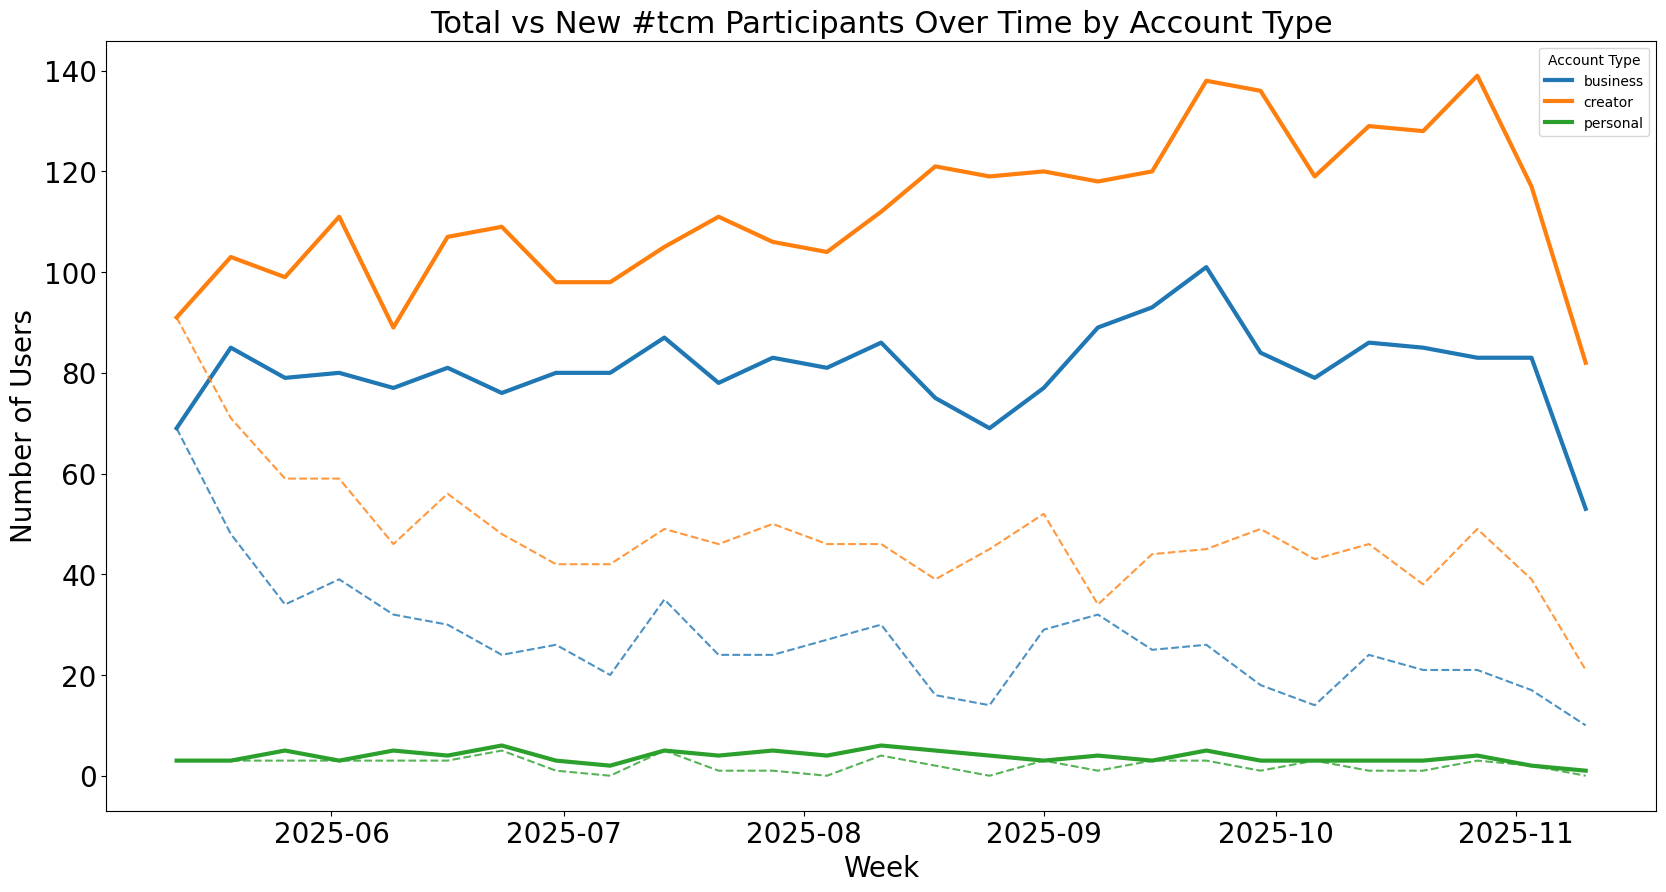

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize=(20,10))

# total unique users (solid)
sns.lineplot(
    data=df_tcm,
    x="week",
    y="unique_owners",
    hue="post_owner.type",
    linewidth=3
)

# new users (dashed style via alpha)
sns.lineplot(
    data=df_tcm,
    x="week",
    y="new_users",
    hue="post_owner.type",
    linestyle="--",
    alpha=0.8,
    legend=False  # avoids duplicate legend
)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel("Week", fontsize=20)
plt.ylabel("Number of Users", fontsize=20)
plt.title("Total vs New #tcm Participants Over Time by Account Type", fontsize=22)

plt.legend(title="Account Type")
plt.show()

plt.savefig("../Output/tcm_total_new_users_over_time.png")

ValueError: Could not interpret value `proportion` for `y`. An entry with this name does not appear in `data`.

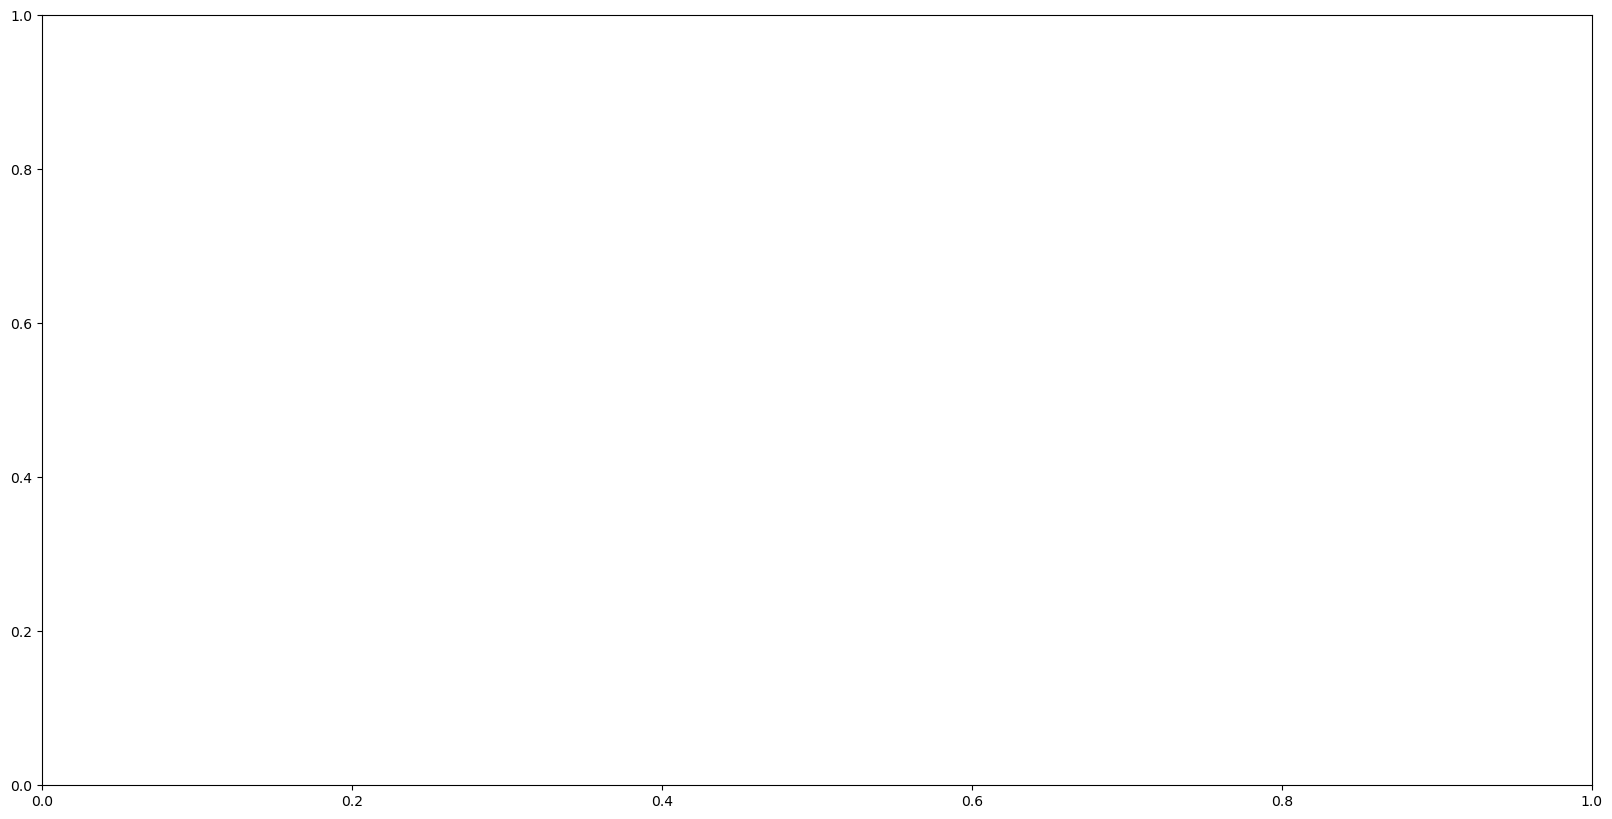

In [27]:
fig, ax1 = plt.subplots(figsize=(20,10))

# --- Proportion (left axis) ---
sns.lineplot(
    data=df_tcm,
    x="week",
    y="proportion",
    hue="post_owner.type",
    linewidth=3,
    ax=ax1
)

ax1.set_ylabel("Proportion of #tcm Posts", fontsize=20)
ax1.set_xlabel("Week", fontsize=20)

# --- Count (right axis) ---
ax2 = ax1.twinx()

sns.lineplot(
    data=df_tcm,
    x="week",
    y="count",
    hue="post_owner.type",
    linewidth=1,
    alpha=0.9,
    ax=ax2,
    legend=False  # avoid duplicate legend
)

ax2.set_ylabel("Number of Posts", fontsize=20)

# formatting
ax1.tick_params(axis='x', labelsize=20)
ax1.tick_params(axis='y', labelsize=20)
ax2.tick_params(axis='y', labelsize=20)

plt.title("#tcm Posts Over Time: Proportion vs Volume by Account Type", fontsize=22)

plt.legend(title="Account Type")
plt.show()

plt.savefig("../Output/tcm_proportion_vs_volume_over_time_acc_type.png")

In [25]:
## Notes for vic
## 1. what hashtags often pair with #tcm
#separate the #s into a different column from the text 
## 4. Map it over time
# look at businesses vs creators using #tcm over time. 
# Sentiment analysis to understand how people use the hashtags over time, selling products or personal. 